# Exploração de Dados — Tech Challenge

## Visão Geral

Neste notebook realizamos a **exploração e análise inicial** do dataset fornecido no Tech Challenge (FIAP — 1IAST, Fase 1).

O objetivo é entender a estrutura dos dados, identificar padrões, tratar possíveis inconsistências e extrair insights relevantes que sirvam de base para as próximas etapas do projeto.

### O que será feito aqui

- Carregamento e inspeção geral do dataset
- Análise de tipos de dados e valores nulos
- Estatísticas descritivas das variáveis
- Visualizações exploratórias para entender distribuições e relações entre variáveis
- Identificação de outliers e anomalias

> **Dataset:** `desafio_nps_fase_1.csv` — contém registros de pesquisa NPS (Net Promoter Score) com informações de clientes, avaliações e variáveis relacionadas ao serviço.

## Dicionário de Dados

| Campo | Descrição |
|---|---|
| `customer_id` | Identificador único do cliente. |
| `order_id` | Identificador único do pedido. |
| `customer_age` | Idade do cliente. |
| `customer_region` | Região geográfica do cliente. |
| `customer_tenure_months` | Tempo de relacionamento do cliente com a empresa (em meses). |
| `order_value` | Valor total do pedido. |
| `items_quantity` | Quantidade de itens no pedido. |
| `discount_value` | Valor de desconto aplicado ao pedido. |
| `payment_installments` | Número de parcelas do pagamento. |
| `delivery_time_days` | Tempo total de entrega (em dias). |
| `delivery_delay_days` | Quantidade de dias de atraso na entrega. |
| `freight_value` | Valor do frete. |
| `delivery_attempts` | Número de tentativas de entrega. |
| `customer_service_contacts` | Número de contatos do cliente com o atendimento. |
| `resolution_time_days` | Tempo para resolução de problemas (em dias). |
| `complaints_count` | Número de reclamações registradas pelo cliente. |
| `repeat_purchase_30d` | Indica se houve recompra em até 30 dias após o pedido (`0` = não, `1` = sim). |
| `csat_internal_score` | Score interno de satisfação do cliente. |
| `nps_score` | Nota de satisfação do cliente (NPS), variando de 0 a 10, coletada após a experiência de compra. |

### Instalação de bibliotecas

In [1]:
%pip install pandas matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Importação das libs

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
sns.set_theme(style="whitegrid")

In [4]:
df = pd.read_csv('../data/raw/desafio_nps_fase_1.csv')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   str    
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64  
 14  res

### Qualidade dos dados e preparação

Vamos verificar se há valores nulos e se há duplicidade nos registros

In [6]:
df.isnull().sum()

customer_id                  0
customer_age                 0
customer_region              0
customer_tenure_months       0
order_id                     0
order_value                  0
items_quantity               0
discount_value               0
payment_installments         0
delivery_time_days           0
delivery_delay_days          0
freight_value                0
delivery_attempts            0
customer_service_contacts    0
resolution_time_days         0
nps_score                    0
repeat_purchase_30d          0
complaints_count             0
csat_internal_score          0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.drop_duplicates().reset_index(drop=True)

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,2496,51,Sul,96,52496,615.81,6,11.41,2,14,3,28.96,2,1,2,3.7,0,3,4.3
2496,2497,37,Sul,89,52497,73.03,1,36.44,3,12,2,27.42,2,2,7,3.7,0,4,2.5
2497,2498,19,Sudeste,98,52498,522.78,1,4.84,9,2,2,38.94,1,1,1,7.4,0,3,6.2
2498,2499,41,Sul,51,52499,55.87,2,2.11,2,14,5,29.10,3,3,0,2.3,0,5,1.7


In [9]:
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


### Dicionário de Dados

| Campo | Descrição |
|---|---|
| `customer_id` | Identificador único do cliente. |
| `order_id` | Identificador único do pedido. |
| `customer_age` | Idade do cliente. |
| `customer_region` | Região geográfica do cliente. |
| `customer_tenure_months` | Tempo de relacionamento do cliente com a empresa (em meses). |
| `order_value` | Valor total do pedido. |
| `items_quantity` | Quantidade de itens no pedido. |
| `discount_value` | Valor de desconto aplicado ao pedido. |
| `payment_installments` | Número de parcelas do pagamento. |
| `delivery_time_days` | Tempo total de entrega (em dias). |
| `delivery_delay_days` | Quantidade de dias de atraso na entrega. |
| `freight_value` | Valor do frete. |
| `delivery_attempts` | Número de tentativas de entrega. |
| `customer_service_contacts` | Número de contatos do cliente com o atendimento. |
| `resolution_time_days` | Tempo para resolução de problemas (em dias). |
| `complaints_count` | Número de reclamações registradas pelo cliente. |
| `repeat_purchase_30d` | Indica se houve recompra em até 30 dias após o pedido (`0` = não, `1` = sim). |
| `csat_internal_score` | Score interno de satisfação do cliente. |
| `nps_score` | Nota de satisfação do cliente (NPS), variando de 0 a 10, coletada após a experiência de compra. 

### Classificação dos Clientes por NPS

Para facilitar as visualizações e análises seguintes, vamos categorizar cada cliente com base na sua nota NPS em três grupos:

- **Detrator** (nota 0–6): clientes insatisfeitos, com alto risco de churn e impacto negativo na marca
- **Neutro** (nota 7–8): clientes satisfeitos, mas sem engajamento ativo
- **Promotor** (nota 9–10): clientes entusiastas, que recomendam o serviço

A seguir, criamos a coluna `nps_class` no dataframe aplicando essa classificação e exibimos as primeiras linhas para validar o resultado.

### Classificação dos Clientes por NPS

Para facilitar as visualizações e análises seguintes, vamos categorizar cada cliente com base na sua nota NPS em três grupos:

- **Detrator** (nota 0–6): clientes insatisfeitos, com alto risco de churn e impacto negativo na marca
- **Neutro** (nota 7–8): clientes satisfeitos, mas sem engajamento ativo
- **Promotor** (nota 9–10): clientes entusiastas, que recomendam o serviço

A seguir, criamos a coluna `nps_class` no dataframe aplicando essa classificação e exibimos as primeiras linhas para validar o resultado.

In [10]:

def categorize_nps(score):
    if score <= 6: return 'Detrator'
    elif score <= 8: return 'Neutro'
    else: return 'Promotor'

df['nps_class'] = df['nps_score'].apply(categorize_nps)

df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,nps_class
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5,Neutro
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0,Detrator
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5,Detrator
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3,Detrator
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9,Neutro


### % de detratores na base

In [11]:
df['nps_class'].value_counts(normalize=True)

nps_class
Detrator    0.7404
Neutro      0.1792
Promotor    0.0804
Name: proportion, dtype: float64

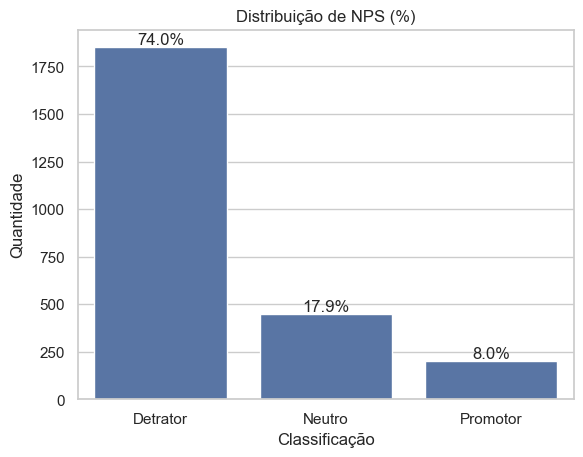

In [12]:
ax = sns.countplot(data=df, x='nps_class', order=['Detrator', 'Neutro', 'Promotor'])

total = len(df)

for p in ax.patches:
    height = p.get_height()
    percentage = 100 * height / total
    ax.annotate(f'{percentage:.1f}%', 
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom')

plt.title('Distribuição de NPS (%)')
plt.xlabel('Classificação')
plt.ylabel('Quantidade')
plt.show()

### Visão geral por perfil de cliente


In [13]:
df.groupby('nps_class').agg({
    'customer_age': 'mean',
    'customer_tenure_months': 'mean',
    'order_value': 'mean',
    'items_quantity': 'mean',
    'delivery_time_days': 'mean',
    'delivery_delay_days': 'mean',
    'customer_service_contacts': 'mean',
    'complaints_count': 'mean'
}).round(2)

,customer_age,customer_tenure_months,order_value,items_quantity,delivery_time_days,delivery_delay_days,customer_service_contacts,complaints_count
nps_class,,,,,,,,
Detrator,43.31,61.58,428.99,3.49,8.00,2.53,1.69,4.62
Neutro,43.45,59.51,447.33,3.35,8.12,1.40,1.13,2.99
Promotor,44.08,63.04,453.69,3.51,8.04,0.76,0.78,2.39


### Gráfico 1 — Impacto do Atraso na Entrega no NPS

A seguir, plotamos um **boxplot** comparando os dias de atraso na entrega entre as três classes de NPS (Detrator, Neutro e Promotor).

O objetivo é verificar se clientes que sofreram maiores atrasos tendem a dar notas mais baixas, evidenciando o impacto direto da logística na satisfação do cliente.

### 

/var/folders/gv/94dx_jhs6357fhh59t8g4_840000gn/T/ipykernel_15562/1914804162.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='nps_class', y='delivery_delay_days', data=df, order=['Detrator', 'Neutro', 'Promotor'], palette='Set2')


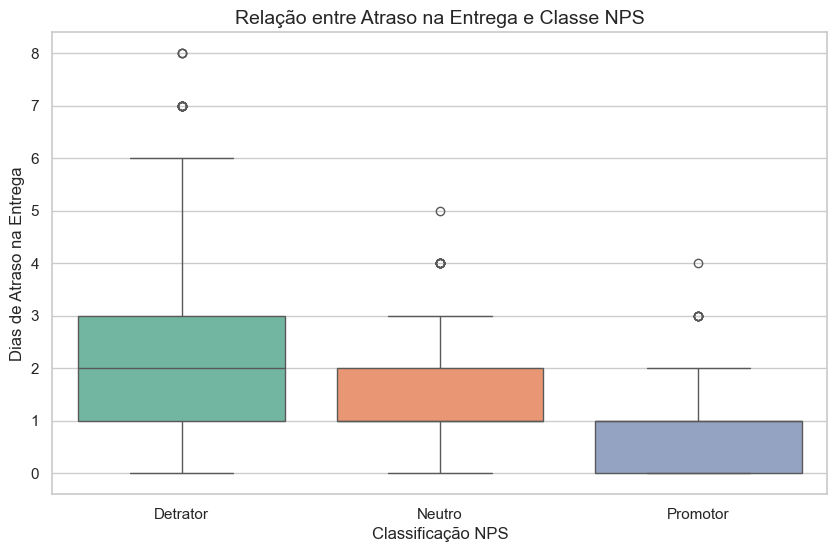

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='nps_class', y='delivery_delay_days', data=df, order=['Detrator', 'Neutro', 'Promotor'], palette='Set2')
plt.title('Relação entre Atraso na Entrega e Classe NPS', fontsize=14)
plt.xlabel('Classificação NPS', fontsize=12)
plt.ylabel('Dias de Atraso na Entrega', fontsize=12)
plt.show()

### Gráfico 2 — Impacto do Atendimento ao Cliente no NPS

A seguir, plotamos um **barplot** com a média de contatos com o atendimento ao cliente para cada classe de NPS (Detrator, Neutro e Promotor).

A hipótese é que clientes Detratores acionam o suporte com muito mais frequência, indicando que a experiência ruim com o atendimento está diretamente associada a notas mais baixas no NPS.

/var/folders/gv/94dx_jhs6357fhh59t8g4_840000gn/T/ipykernel_15562/1780649110.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='nps_class', y='customer_service_contacts', data=df, order=['Detrator', 'Neutro', 'Promotor'], palette='Set1')


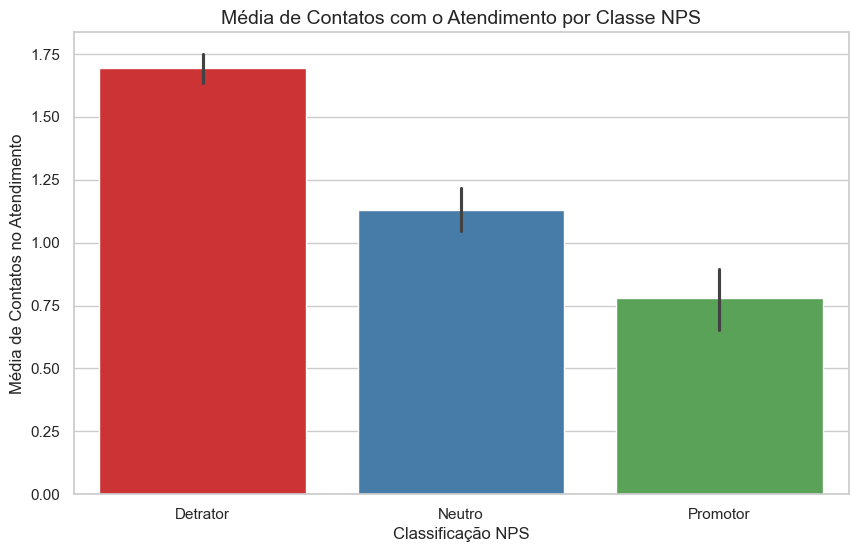

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(x='nps_class', y='customer_service_contacts', data=df, order=['Detrator', 'Neutro', 'Promotor'], palette='Set1')
plt.title('Média de Contatos com o Atendimento por Classe NPS', fontsize=14)
plt.xlabel('Classificação NPS', fontsize=12)
plt.ylabel('Média de Contatos no Atendimento', fontsize=12)
plt.show()

### Gráfico 3 — Correlação das Variáveis com a Nota de NPS

Agora vamos analisar **o que mais influencia a nota de NPS** através de um **heatmap de correlação**.

Calculamos a correlação entre a variável `nps_score` e as principais variáveis numéricas do dataset:

- `delivery_delay_days` — dias de atraso na entrega
- `customer_service_contacts` — número de contatos com o suporte
- `delivery_time_days` — tempo total de entrega
- `freight_value` — valor do frete

Valores próximos de **-1** indicam forte correlação negativa (quanto maior a variável, menor o NPS), enquanto valores próximos de **+1** indicam correlação positiva.

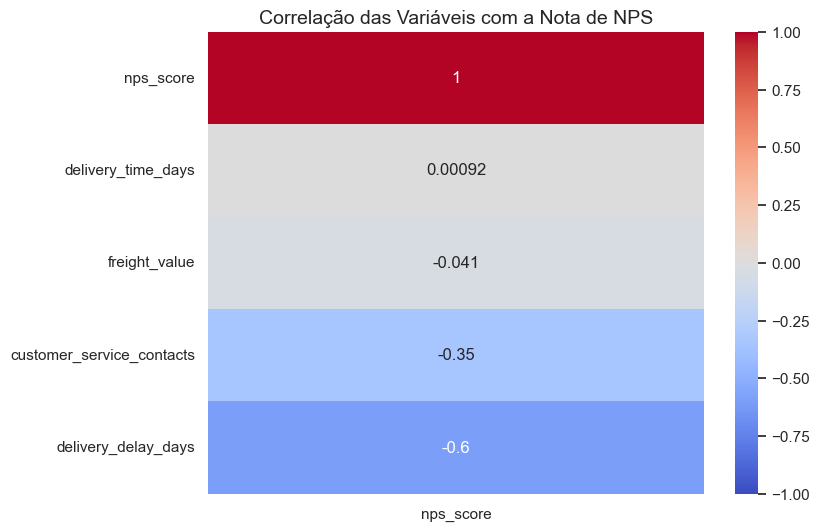

In [16]:
colunas_numericas = ['nps_score', 'delivery_delay_days', 'customer_service_contacts', 'delivery_time_days', 'freight_value']
correlacao = df[colunas_numericas].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlacao[['nps_score']].sort_values(by='nps_score', ascending=False),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlação das Variáveis com a Nota de NPS', fontsize=14)
plt.show()

### Análise por Região

Agora vamos agrupar os dados pela coluna `customer_region` para entender como o NPS varia entre as diferentes regiões do país.

Essa análise permite identificar regiões com maior concentração de Detratores ou Promotores, ajudando a direcionar ações de melhoria de forma mais segmentada.

In [17]:
df_per_region = df.groupby('customer_region').agg(
    media_nps=('nps_score', 'mean'),
    total_clientes=('nps_score', 'count'),
    detratores=('nps_class', lambda x: (x == 'Detrator').sum()),
    neutros=('nps_class', lambda x: (x == 'Neutro').sum()),
    promotores=('nps_class', lambda x: (x == 'Promotor').sum()),
).round(2).sort_values('media_nps')

df_per_region

,media_nps,total_clientes,detratores,neutros,promotores
customer_region,,,,,
Centro-Oeste,4.21,468,348,84,36
Sudeste,4.37,520,388,89,43
Norte,4.38,506,377,91,38
Nordeste,4.42,485,359,92,34
Sul,4.49,521,379,92,50


### Gráfico 4 — Média de NPS por Região

A seguir, plotamos um **barplot** com a média de NPS por região, permitindo visualizar rapidamente quais regiões apresentam melhor e pior desempenho em satisfação do cliente.

e separando por região poderamos tabém visualizar melhor os motivos da nota de nps por cada região

/var/folders/gv/94dx_jhs6357fhh59t8g4_840000gn/T/ipykernel_15562/2204662901.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


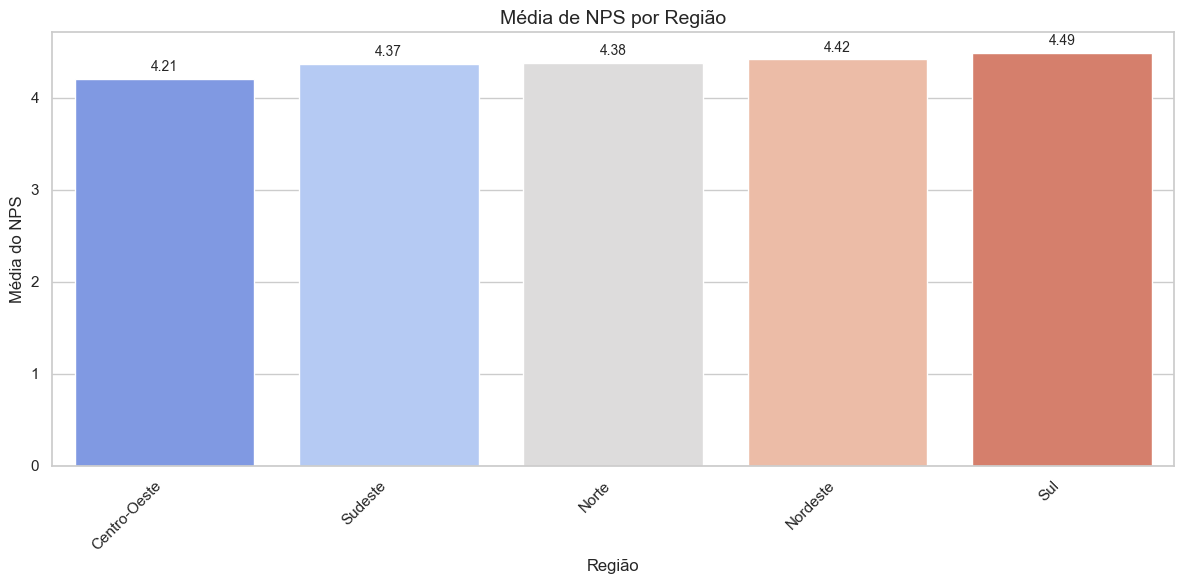

In [18]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=df_per_region.reset_index(),
    x='customer_region',
    y='media_nps',
    palette='coolwarm',
    order=df_per_region.index
)
plt.title('Média de NPS por Região', fontsize=14)
plt.xlabel('Região', fontsize=12)
plt.ylabel('Média do NPS', fontsize=12)
plt.xticks(rotation=45, ha='right')

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f'{bar.get_height():.2f}',
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()

### Correlação entre NPS e Variáveis do Dataset por Região

Agora que segmentamos os clientes por região, vamos aprofundar a análise verificando como cada variável operacional se correlaciona com o NPS em cada região.

Para cada uma das variáveis abaixo, plotaremos um gráfico de barras com a **média da variável por região**, lado a lado com a média de NPS, para identificar padrões regionais:

- `customer_age` — idade do cliente
- `items_quantity` — quantidade de itens no pedido
- `discount_value` — valor de desconto aplicado
- `payment_installments` — número de parcelas do pagamento
- `delivery_time_days` — tempo total de entrega
- `delivery_delay_days` — dias de atraso na entrega

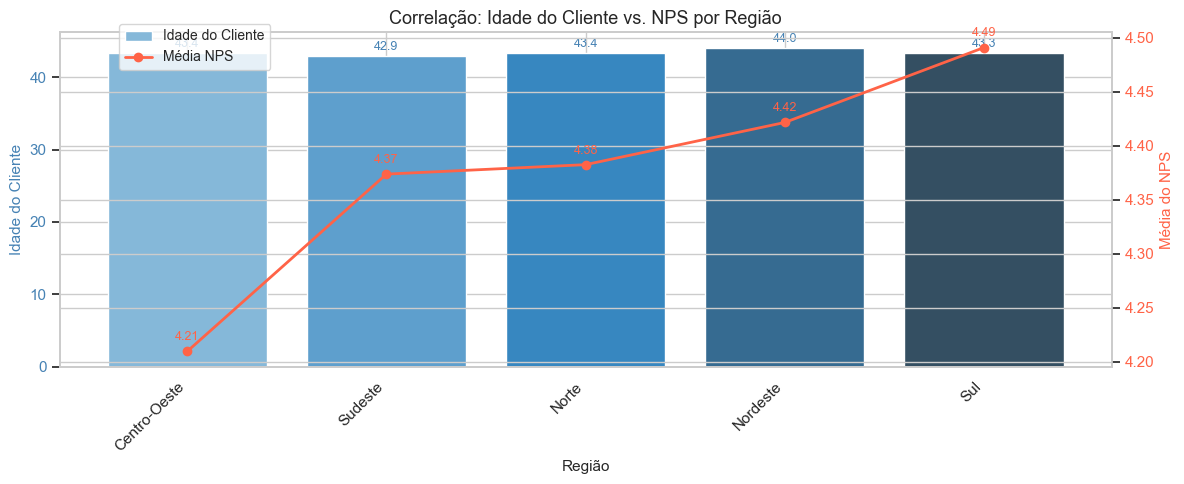

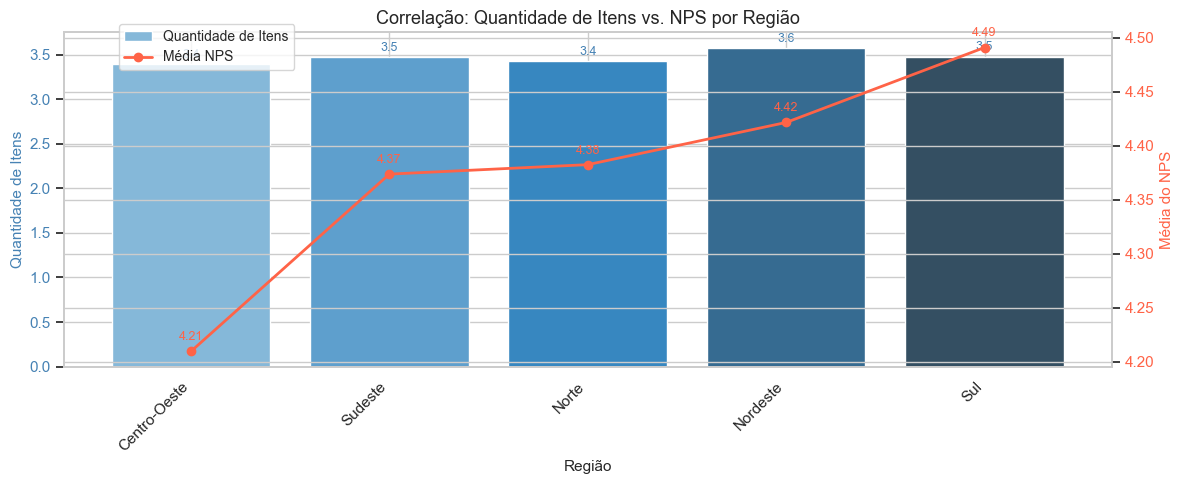

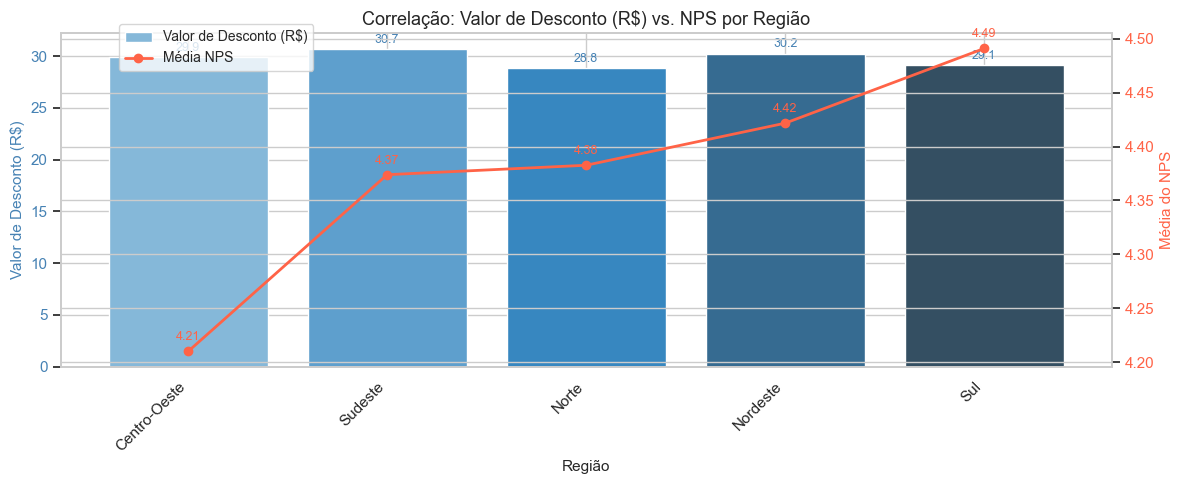

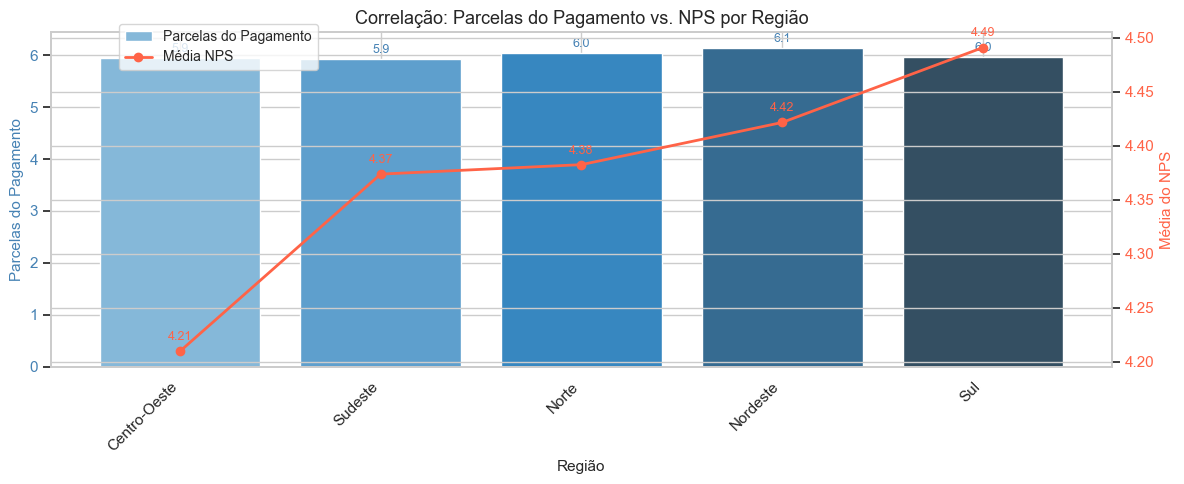

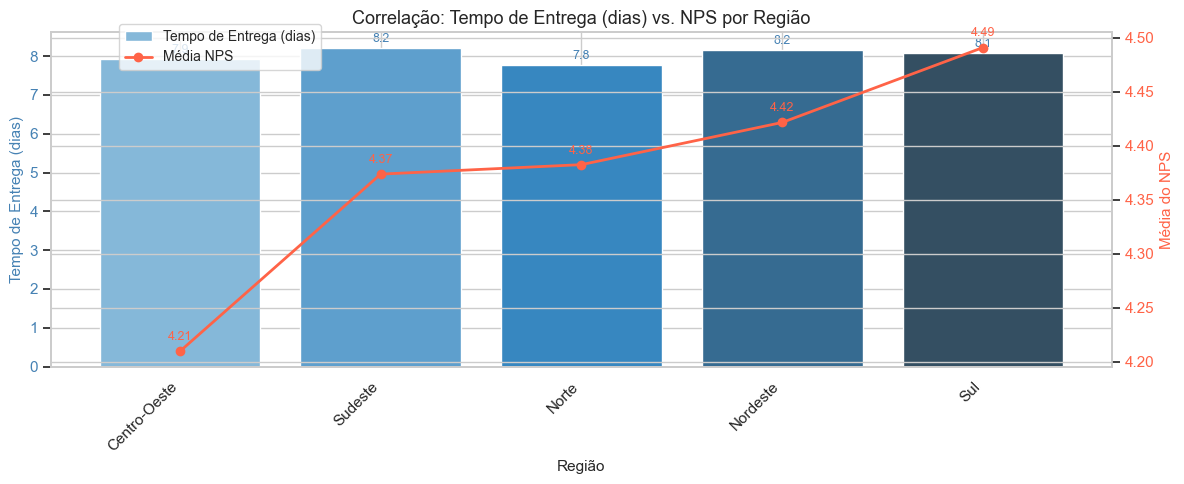

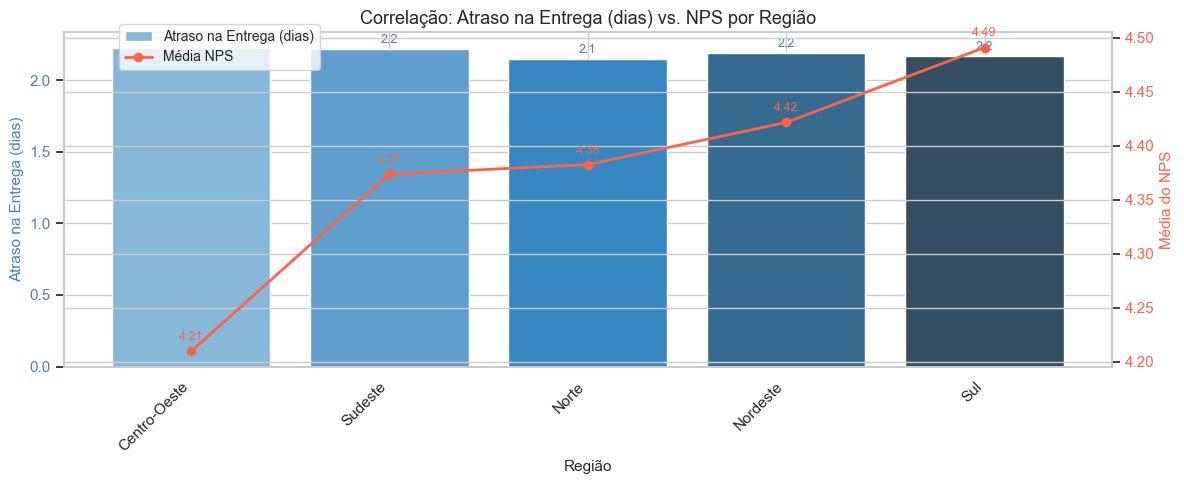

In [19]:
variables = {
    'customer_age': 'Idade do Cliente',
    'items_quantity': 'Quantidade de Itens',
    'discount_value': 'Valor de Desconto (R$)',
    'payment_installments': 'Parcelas do Pagamento',
    'delivery_time_days': 'Tempo de Entrega (dias)',
    'delivery_delay_days': 'Atraso na Entrega (dias)',
}

regioes_order = df.groupby('customer_region')['nps_score'].mean().sort_values().index.tolist()

for coluna, label in variables.items():
    media_var = df.groupby('customer_region')[coluna].mean().reindex(regioes_order)
    media_nps = df.groupby('customer_region')['nps_score'].mean().reindex(regioes_order)

    fig, ax1 = plt.subplots(figsize=(12, 5))

    cor_barras = sns.color_palette('Blues_d', len(regioes_order))
    bars = ax1.bar(regioes_order, media_var, color=cor_barras, label=label, zorder=2)
    ax1.set_ylabel(label, fontsize=11, color='steelblue')
    ax1.tick_params(axis='y', labelcolor='steelblue')
    ax1.set_xlabel('Região', fontsize=11)
    plt.xticks(rotation=45, ha='right')

    for bar in bars:
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + bar.get_height() * 0.01,
            f'{bar.get_height():.1f}',
            ha='center', va='bottom', fontsize=9, color='steelblue'
        )

    ax2 = ax1.twinx()
    ax2.plot(regioes_order, media_nps, color='tomato', marker='o', linewidth=2, label='Média NPS', zorder=3)
    ax2.set_ylabel('Média do NPS', fontsize=11, color='tomato')
    ax2.tick_params(axis='y', labelcolor='tomato')

    for x, y in zip(regioes_order, media_nps):
        ax2.annotate(f'{y:.2f}', (x, y), textcoords='offset points', xytext=(0, 8),
                     ha='center', fontsize=9, color='tomato')

    plt.title(f'Correlação: {label} vs. NPS por Região', fontsize=13)
    fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.95), fontsize=10)
    plt.tight_layout()
    plt.show()

### Gráfico 5 — Quantidade de Clientes por Região

A seguir, visualizamos a **distribuição de clientes** entre as regiões, permitindo entender se as diferenças de NPS observadas anteriormente podem estar relacionadas ao volume de clientes em cada região.

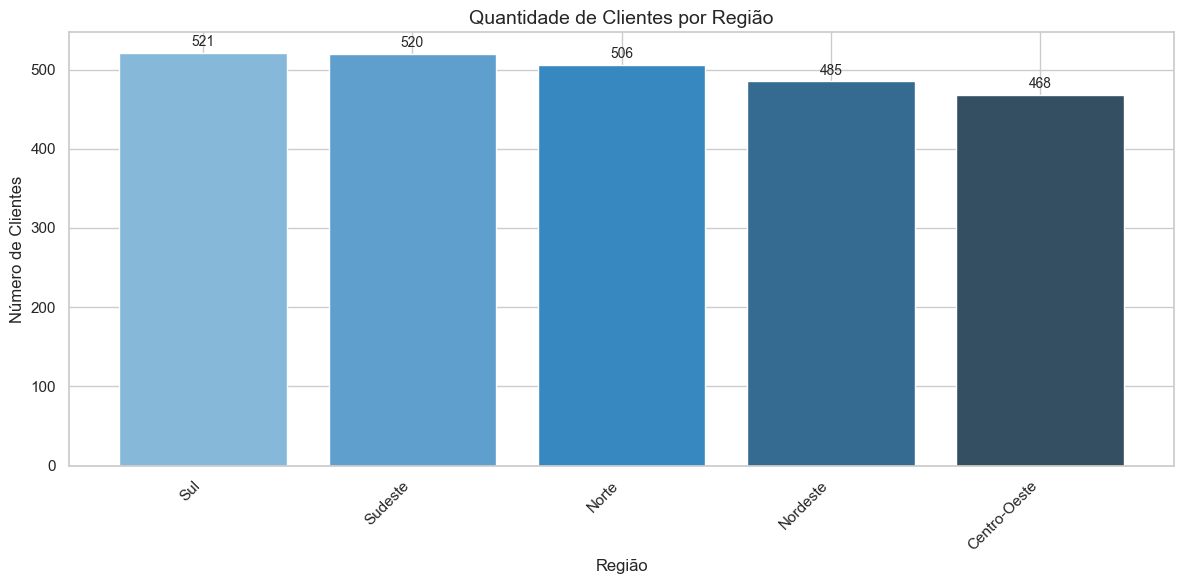

In [20]:
clientes_por_regiao = df['customer_region'].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))

cores = sns.color_palette('Blues_d', len(clientes_por_regiao))
bars = ax.bar(clientes_por_regiao.index, clientes_por_regiao.values, color=cores)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + bar.get_height() * 0.01,
        f'{int(bar.get_height())}',
        ha='center', va='bottom', fontsize=10
    )

ax.set_title('Quantidade de Clientes por Região', fontsize=14)
ax.set_xlabel('Região', fontsize=12)
ax.set_ylabel('Número de Clientes', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Gráfico 6 — Distribuição de Idade dos Clientes por Região

A seguir, visualizamos a **distribuição de idades** dos clientes em cada região para entender se o perfil etário varia entre as regiões.

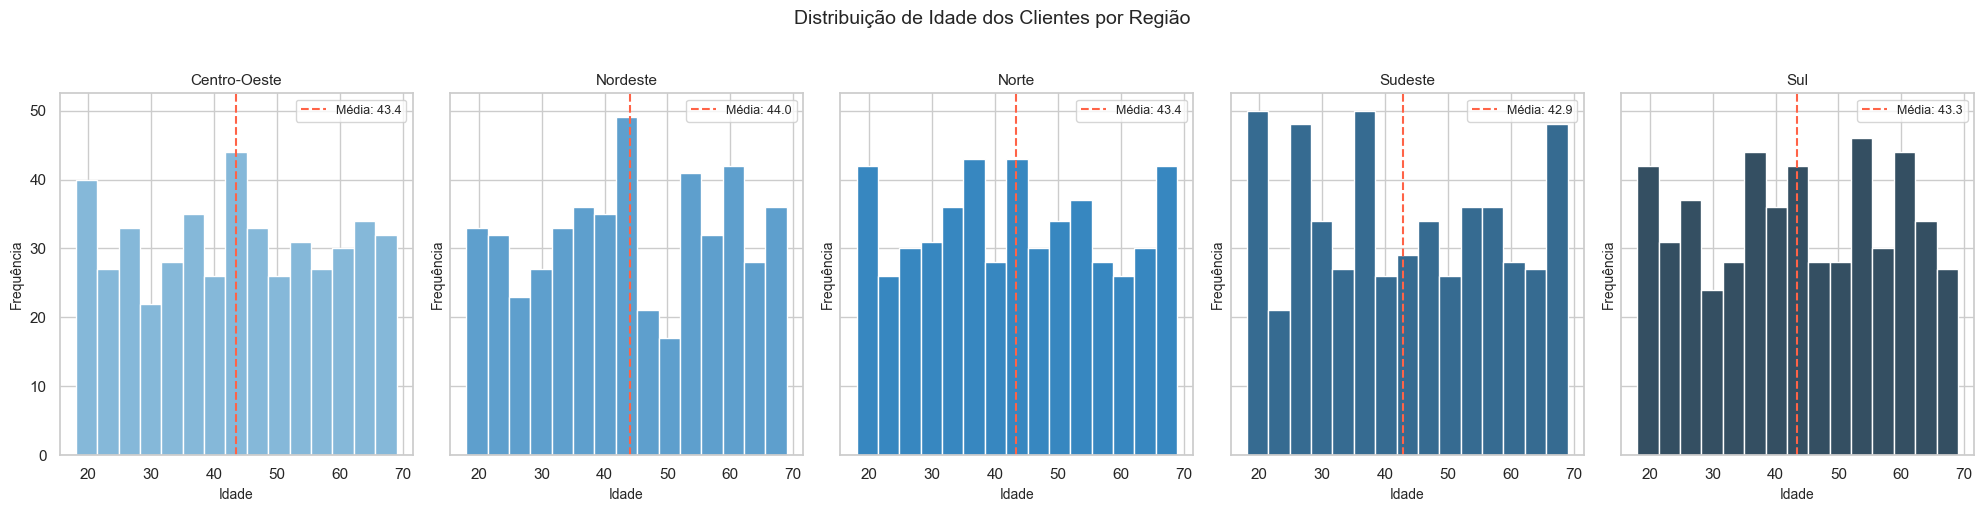

In [21]:
regioes = df['customer_region'].unique()
n_regioes = len(regioes)

fig, axes = plt.subplots(1, n_regioes, figsize=(4 * n_regioes, 5), sharey=True)

cores = sns.color_palette('Blues_d', n_regioes)

for ax, regiao, cor in zip(axes, sorted(regioes), cores):
    dados = df[df['customer_region'] == regiao]['customer_age']
    ax.hist(dados, bins=15, color=cor, edgecolor='white')
    ax.set_title(regiao, fontsize=11)
    ax.set_xlabel('Idade', fontsize=10)
    ax.set_ylabel('Frequência', fontsize=10)
    ax.axvline(dados.mean(), color='tomato', linestyle='--', linewidth=1.5, label=f'Média: {dados.mean():.1f}')
    ax.legend(fontsize=9)

plt.suptitle('Distribuição de Idade dos Clientes por Região', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Painel de Insights — Conectando os Pontos

Até aqui, vimos:

- Como o NPS se distribui entre os clientes e como eles se classificam em **Detratores**, **Neutros** e **Promotores**;
- Como variáveis operacionais — como atraso na entrega e contatos com atendimento — impactam diretamente a satisfação;
- Quais regiões se destacam positiva ou negativamente no NPS médio;
- Como o perfil etário dos clientes se distribui por região.

Nesta seção, o foco é **síntese**. Em vez de novos gráficos, vamos conectar os achados em uma narrativa:

---

### Principais padrões observados

- **Atraso na entrega é o principal vilão do NPS.** O boxplot deixou evidente que clientes detratores acumulam muito mais dias de atraso do que neutros e promotores. Reduzir o atraso é provavelmente a alavanca com maior impacto direto na nota de satisfação.

- **Volume de contatos com atendimento sinaliza insatisfação.** Clientes que precisaram acionar o suporte com mais frequência tendem a dar notas menores. Isso sugere que problemas operacionais não resolvidos na primeira interação geram frustração cumulativa.

- **A correlação entre variáveis e NPS é mais clara nas variáveis de serviço.** Variáveis como `delivery_delay_days` e `customer_service_contacts` mostraram correlação negativa consistente com o NPS, enquanto variáveis como `customer_age` e `items_quantity` apresentaram relação mais fraca.

---

### Desigualdades regionais evidentes

- As regiões apresentam diferenças relevantes na média de NPS, o que pode refletir tanto a qualidade da operação logística local quanto o perfil de expectativa dos clientes.

- Regiões com maior volume de clientes não necessariamente têm melhor NPS — o que indica que a escala não está trazendo ganhos de qualidade de forma uniforme.

- O perfil etário é relativamente homogêneo entre regiões, sugerindo que as diferenças de NPS não são explicadas pela idade dos clientes, mas sim por fatores operacionais e de atendimento.

---

### Relações mais fortes entre variáveis

- **Entrega × NPS:** A variável `delivery_delay_days` é a que apresenta relação mais forte e direta com a nota de NPS — quanto maior o atraso, menor a satisfação.

- **Atendimento × NPS:** A frequência de contatos com o suporte (`customer_service_contacts`) também se mostrou negativamente correlacionada com o NPS, reforçando que a experiência pós-venda tem peso elevado na percepção do cliente.

---

### Casos especiais e análises futuras

- Vale investigar **quais regiões concentram os maiores atrasos de entrega** e cruzar com os piores índices de NPS para identificar gargalos logísticos específicos.

- Clientes com **alto número de reclamações e baixo NPS** formam um grupo prioritário para ações de recuperação — seria interessante segmentá-los e analisar padrões em comum.

- A variável `repeat_purchase_30d` pode ser explorada em uma análise de **retenção**: clientes promotores recompram mais? Detratores abandonam a base? Essa relação pode embasar estratégias de fidelização.

## Conclusões e Próximos Passos

Neste notebook, usamos o dataset de NPS como base para exercitar a **exploração e análise de dados orientada a negócio**:

- Partimos de perguntas claras sobre satisfação do cliente e seus determinantes;
- Exploramos a estrutura e a qualidade da base, verificando nulos e duplicatas;
- Classificamos os clientes em **Detratores**, **Neutros** e **Promotores** para enriquecer a análise;
- Construímos visualizações que revelaram o impacto do atraso na entrega, do atendimento ao cliente e de outras variáveis operacionais no NPS;
- Segmentamos os dados por região, identificando diferenças no perfil de satisfação e no volume de clientes;
- Organizamos os achados em uma narrativa coerente, conectando padrões e levantando hipóteses.

